# 04. Validation readiness, transfer, and segment safety

This notebook produces the Section 5.3 experiment. It freezes the season-two catalog and replay logic, evaluates out-of-time transfer on season three, and checks whether the priority policy hides harm across advertiser, exchange, and region segments.

In [1]:
from pathlib import Path
import sys

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "src").is_dir() and (candidate / "notebooks").is_dir():
        CODE_ROOT = candidate
        break
    if (candidate / "code" / "src").is_dir() and (candidate / "code" / "notebooks").is_dir():
        CODE_ROOT = candidate / "code"
        break
else:
    raise RuntimeError("Could not find the project code root.")

sys.path.insert(0, str(CODE_ROOT / "src"))

from IPython.display import Image, display

from config import ExperimentConfig, ProjectPaths
from paper_experiments import (
    build_ipinyou_panels,
    run_appendix_b_diagnostics,
    run_conservative_shortlist,
    run_data_audit,
    run_support_localized_threshold_resolution,
    run_validation_readiness,
)
from progress import ProgressLogger

paths = ProjectPaths.from_repo_root(CODE_ROOT)
paths.ensure()
config = ExperimentConfig(full_run=True)
progress = ProgressLogger(enabled=True)
print(f"Code root: {CODE_ROOT}")
print(f"Data archive: {paths.ipinyou_archive}")
print(f"Artifacts: {paths.artifact_dir}")

Code root: <repo>
Data archive: <repo>/data/archive.zip
Artifacts: <repo>/artifacts


[02:25:21] >> Running Section 5.3 validation-readiness experiment.
[02:25:23]    Using cached Season 2 replay effects: 02_season2_replay_policy_effects.csv.
[02:25:23]    Replaying policies on ipinyou_season3_20131019.parquet.
[02:25:23]    Replaying policies on ipinyou_season3_20131020.parquet.
[02:25:24]    Replaying policies on ipinyou_season3_20131021.parquet.
[02:25:26]    Replaying policies on ipinyou_season3_20131022.parquet.
[02:25:28]    Replaying policies on ipinyou_season3_20131023.parquet.
[02:25:30]    Replaying policies on ipinyou_season3_20131024.parquet.
[02:25:32]    Replaying policies on ipinyou_season3_20131025.parquet.
[02:25:35]    Replaying policies on ipinyou_season3_20131026.parquet.
[02:25:35]    Replaying policies on ipinyou_season3_20131027.parquet.
[02:25:38]    Computing segment safety for advertiser_id.
[02:25:51]    Computing segment safety for ad_exchange.
[02:26:04]    Computing segment safety for region.
[02:26:19] OK Section 5.3 artifacts are ready. (

,check,value
0,season_three_rank_of_priority_policy,1.000000
1,covered_segment_count,44.000000
2,segments_with_nonnegative_lower_bar,44.000000
3,minimum_segment_lower_bar,0.296117


,policy_id,policy_number,policy_label,policy_family,season2_replay_lift,season2_rank,season3_replay_lift,retained_impression_share,season3_rank,rank_shift
0,hybrid_q75_if_gap_100,P18,Q75 Margin-Gated Floor,hybrid_quantile_margin,0.476604,1.0,0.438722,1.000000,1.0,0.0
1,min_positive_floor_q75,P11,Positive Floors To Q75,positive_floor_quantile,0.355075,2.0,0.299696,1.000000,2.0,0.0
2,zero_and_low_floor_to_q50,P13,All Low Floors To Q50,all_floor_quantile,0.101179,3.0,0.123098,1.000000,3.0,0.0
3,hybrid_q50_if_gap_50,P17,Q50 Margin-Gated Floor,hybrid_quantile_margin,0.101179,3.0,0.123098,1.000000,3.0,0.0
4,margin_gap_100_add_20,P16,Gap 100 Add 20,margin_increment,0.097883,5.0,0.075945,1.000000,7.0,2.0
5,add_20_all_floors,P8,Add 20 To All Floors,absolute_increment,0.097433,6.0,0.081185,0.999515,6.0,0.0
6,min_positive_floor_q50,P10,Positive Floors To Q50,positive_floor_quantile,0.072978,7.0,0.085755,1.000000,5.0,-2.0
7,uniform_raise_30pct,P5,Uniform +30%,uniform_percent,0.069190,8.0,0.040003,0.994047,8.0,0.0
8,uniform_raise_20pct,P4,Uniform +20%,uniform_percent,0.044008,9.0,0.035150,0.998742,11.0,2.0
9,margin_gap_50_add_10,P15,Gap 50 Add 10,margin_increment,0.040727,10.0,0.037351,1.000000,9.0,-1.0


,segment_column,segment,mean_lift,sd_lift,days,opportunities,standard_error,lower_bar,upper_bar,passes_nonharm_bar,days_required_for_nonharm_bar,additional_days_required,alpha,min_segment_observations
0,advertiser_id,3358,0.330576,0.046516,7,3751016,0.017581,0.296117,0.365035,True,1.0,0.0,0.05,1000
1,ad_exchange,1,0.316612,0.019138,7,6117330,0.007233,0.302435,0.330789,True,1.0,0.0,0.05,1000
2,region,79,0.343427,0.018680,7,1246099,0.007060,0.329589,0.357265,True,1.0,0.0,0.05,1000
3,region,298,0.421783,0.061638,7,914536,0.023297,0.376121,0.467444,True,1.0,0.0,0.05,1000
4,region,359,0.464619,0.114810,7,230500,0.043394,0.379568,0.549670,True,1.0,0.0,0.05,1000
5,region,2,0.430284,0.066699,7,558828,0.025210,0.380874,0.479695,True,1.0,0.0,0.05,1000
6,region,15,0.439494,0.077966,7,940197,0.029468,0.381737,0.497251,True,1.0,0.0,0.05,1000
7,region,164,0.437549,0.071282,7,2264187,0.026942,0.384744,0.490355,True,1.0,0.0,0.05,1000
8,region,308,0.434186,0.063558,7,1253864,0.024023,0.387103,0.481269,True,1.0,0.0,0.05,1000
9,advertiser_id,3427,0.432094,0.059828,7,14032619,0.022613,0.387773,0.476415,True,1.0,0.0,0.05,1000


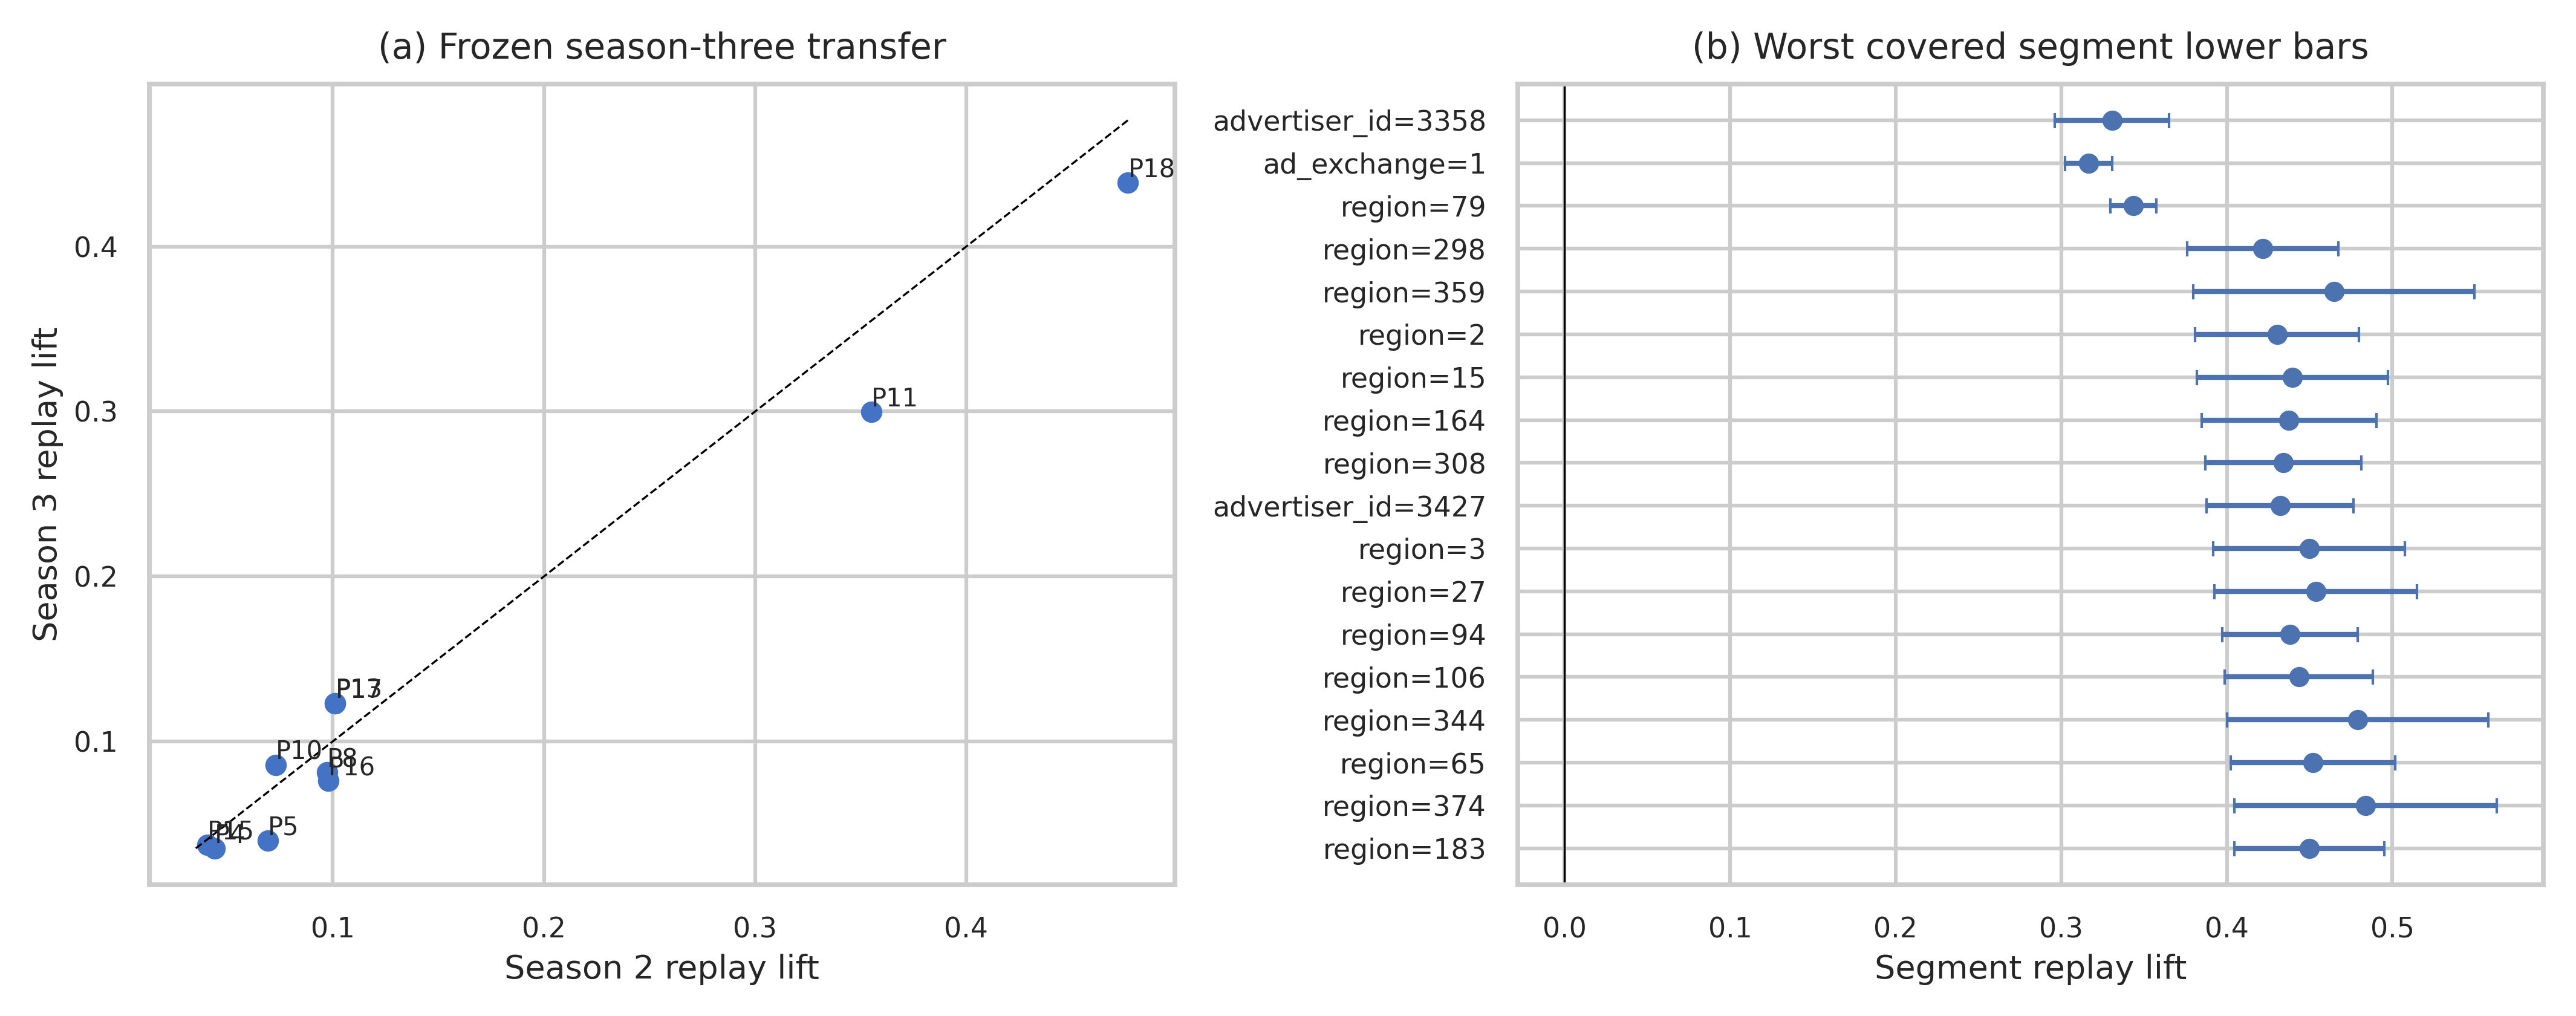

In [2]:
artifacts = run_validation_readiness(paths, config, progress)

display(artifacts["readiness"])
display(artifacts["transfer"].head(10))
display(artifacts["segment_summary"].sort_values("lower_bar").head(12))
display(Image(filename=str(artifacts["figure"])))